# Dataset Validation and Quality Assessment

## Objective

Before building the preprocessing pipeline and training deep learning models, it is essential to validate the integrity and consistency of the BraTS2020 dataset.

This notebook performs a comprehensive quality assessment of the dataset to ensure that all MRI volumes and segmentation masks are complete, correctly formatted, and consistent across all patients.

The validation results will be used as the foundation for the preprocessing stage.

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd

import nibabel as nib
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [2]:
DATASET_PATH = Path(
    "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
)

## Loading Patient Directories

The first validation step is to identify all available patient folders inside the dataset.

In [3]:
patients = sorted(
    [p for p in DATASET_PATH.iterdir() if p.is_dir()]
)

print(f"Total Patients: {len(patients)}")

Total Patients: 369


## Validation Check 1

Verify that every patient folder contains exactly five files.

In [4]:
expected_files = 5

invalid_patients = []

for patient in patients:

    files = list(patient.glob("*.nii"))

    if len(files) != expected_files:
        invalid_patients.append(patient.name)

print(f"Invalid Patients: {len(invalid_patients)}")

if len(invalid_patients) == 0:
    print("✅ All patient folders contain exactly five MRI files.")
else:
    print(invalid_patients)

Invalid Patients: 0
✅ All patient folders contain exactly five MRI files.


# Validation Check 2 — File Naming Convention

Each patient folder should contain exactly five files following the BraTS2020 naming convention.

Expected modalities:

- flair
- t1
- t1ce
- t2
- seg

Validating file names ensures that the dataset loader can automatically locate MRI modalities without relying on hardcoded paths.

In [5]:
def get_modality(file_path: Path):
    """
    Extract MRI modality from a BraTS filename.
    """

    name = file_path.stem.lower()

    if "flair" in name:
        return "flair"

    elif "t1ce" in name:
        return "t1ce"

    elif "_t1" in name:
        return "t1"

    elif "t2" in name:
        return "t2"

    elif "seg" in name:
        return "seg"

    return None

In [6]:
EXPECTED_MODALITIES = {
    "flair",
    "t1",
    "t1ce",
    "t2",
    "seg"
}

invalid_naming = []

for patient in tqdm(patients):

    found = set()

    for file in patient.glob("*.nii"):

        modality = get_modality(file)

        if modality is not None:
            found.add(modality)

    if found != EXPECTED_MODALITIES:
        invalid_naming.append(patient.name)

print("Patients with Invalid Naming:", len(invalid_naming))

  0%|          | 0/369 [00:00<?, ?it/s]

Patients with Invalid Naming: 0


In [7]:
if len(invalid_naming) == 0:
    print("✅ All patients follow the official BraTS2020 naming convention.")
else:
    print(invalid_naming)

✅ All patients follow the official BraTS2020 naming convention.


### Observation

During the validation process, one patient (`BraTS20_Training_355`) was found to contain a segmentation file with a different filename (`W39_1998.09.19_Segm.nii`).

Although the filename differs from the standard BraTS naming convention, the file is still a valid segmentation mask.

Instead of modifying the raw dataset, the validation pipeline was designed to recognize segmentation files based on their modality keyword (`seg`) rather than relying on an exact filename.

This approach makes the pipeline more robust and compatible with minor naming inconsistencies.

# Validation Check 3 — MRI Volume Shape Validation

One of the most important validation steps is verifying the spatial dimensions of all MRI volumes.

Medical imaging datasets may contain scans acquired from different scanners or hospitals, resulting in different image sizes.

Since deep learning models require consistent input dimensions, we first inspect the shapes of all MRI volumes before designing the preprocessing pipeline.

In [8]:
from collections import Counter

volume_shapes = []

for patient in tqdm(patients):

    t1_path = next(patient.glob("*_t1.nii"))

    volume = nib.load(str(t1_path))

    volume_shapes.append(volume.shape)

  0%|          | 0/369 [00:00<?, ?it/s]

In [9]:
shape_counter = Counter(volume_shapes)

shape_counter

Counter({(240, 240, 155): 369})

In [10]:
for shape, count in shape_counter.items():
    print(f"{shape} --> {count} patients")

(240, 240, 155) --> 369 patients


### Observation

The MRI volume dimensions were validated across all 369 patients.

Only one unique volume shape was found:

- **(240 × 240 × 155)**

This indicates that the dataset has already been spatially standardized.

Since all MRI volumes share identical dimensions, no spatial resampling will be required to unify image sizes during preprocessing.

This consistency simplifies both dataset preparation and model training.

In [11]:
print(f"Unique Shapes Found: {len(shape_counter)}")

Unique Shapes Found: 1


In [12]:
if len(shape_counter) == 1:
    print("✅ All MRI volumes have identical spatial dimensions.")
else:
    print("⚠️ Multiple MRI shapes detected.")

✅ All MRI volumes have identical spatial dimensions.


# Validation Check 4 — MRI and Segmentation Shape Consistency

For supervised medical image segmentation, every MRI volume must have a corresponding segmentation mask with identical spatial dimensions.

This validation ensures voxel-wise correspondence between MRI scans and segmentation labels.

In [13]:
def get_modality_path(patient_path, modality):

    for file in patient_path.glob("*.nii"):

        name = file.stem.lower()

        if modality == "seg":

            if "seg" in name:
                return file

        else:

            if f"_{modality}" in name:
                return file

    raise FileNotFoundError(
        f"{modality} not found for {patient_path.name}"
    )

In [14]:
shape_mismatch = []

for patient in tqdm(patients):

    t1_path = get_modality_path(patient, "t1")

    seg_path = get_modality_path(patient, "seg")

    mri_shape = nib.load(str(t1_path)).shape

    seg_shape = nib.load(str(seg_path)).shape

    if mri_shape != seg_shape:

        shape_mismatch.append(
            {
                "Patient": patient.name,
                "MRI Shape": mri_shape,
                "Mask Shape": seg_shape,
            }
        )

  0%|          | 0/369 [00:00<?, ?it/s]

In [15]:
print("Patients with Shape Mismatch:", len(shape_mismatch))

if len(shape_mismatch) == 0:
    print("✅ All segmentation masks perfectly match MRI dimensions.")

Patients with Shape Mismatch: 0
✅ All segmentation masks perfectly match MRI dimensions.


### Observation

The spatial dimensions of every MRI volume were compared with its corresponding segmentation mask.

No dimension mismatches were detected.

This confirms that all segmentation masks are perfectly aligned with their MRI volumes and can be directly used for voxel-wise supervised learning.

# Validation Check 5 — Segmentation Label Validation

Segmentation masks should contain only valid BraTS2020 labels.

This validation checks the labels present in every segmentation mask to ensure that no unexpected class values exist.

Understanding the distribution of labels is also important before training the segmentation model.

In [16]:
label_summary = {}

for patient in tqdm(patients):

    seg_path = get_modality_path(patient, "seg")

    mask = nib.load(str(seg_path)).get_fdata()

    labels = tuple(np.unique(mask).astype(int))

    label_summary[patient.name] = labels

  0%|          | 0/369 [00:00<?, ?it/s]

In [17]:
label_counter = Counter(label_summary.values())

label_counter

Counter({(np.int64(0), np.int64(1), np.int64(2), np.int64(4)): 340,
         (np.int64(0), np.int64(2), np.int64(4)): 1,
         (np.int64(0), np.int64(1), np.int64(2)): 27,
         (np.int64(0), np.int64(1), np.int64(4)): 1})

In [18]:
for labels, count in label_counter.items():

    print(labels, " --> ", count, "patients")

(np.int64(0), np.int64(1), np.int64(2), np.int64(4))  -->  340 patients
(np.int64(0), np.int64(2), np.int64(4))  -->  1 patients
(np.int64(0), np.int64(1), np.int64(2))  -->  27 patients
(np.int64(0), np.int64(1), np.int64(4))  -->  1 patients


### Observation

The segmentation masks do not all contain the same combination of labels.

The majority of patients (**340 out of 369**) contain all BraTS2020 labels.

However, several patients are missing one tumor subregion:

| Labels | Number of Patients |
|---------|-------------------:|
| (0,1,2,4) | 340 |
| (0,1,2) | 27 |
| (0,2,4) | 1 |
| (0,1,4) | 1 |

This behavior is expected in medical datasets because not every patient exhibits all tumor subregions.

Therefore, missing labels should **not** be considered data errors.

In [19]:
VALID_LABELS = {0,1,2,4}

invalid_labels = []

for patient, labels in label_summary.items():

    if not set(labels).issubset(VALID_LABELS):

        invalid_labels.append(patient)

print("Patients with Invalid Labels:", len(invalid_labels))

Patients with Invalid Labels: 0


In [20]:
if len(invalid_labels) == 0:
    print("✅ All segmentation masks contain valid BraTS2020 labels.")

✅ All segmentation masks contain valid BraTS2020 labels.


# Validation Check 6 — MRI Intensity Validation

MRI intensity values are not standardized across different scanners or acquisition protocols.

Therefore, we inspect the intensity statistics of every MRI volume before designing the preprocessing pipeline.

For each patient, we compute:

- Minimum intensity
- Maximum intensity
- Mean intensity
- Standard deviation

These statistics will later guide the normalization strategy.

In [21]:
MODALITIES_TO_CHECK = ['flair', 't1', 't1ce', 't2']

intensity_stats = []

for patient in tqdm(patients):

    row = {'Patient': patient.name}

    for modality in MODALITIES_TO_CHECK:

        volume = nib.load(str(get_modality_path(patient, modality))).get_fdata()

        brain = volume[volume > 0]

        row[f'{modality}_min']  = brain.min()
        row[f'{modality}_max']  = brain.max()
        row[f'{modality}_mean'] = brain.mean()
        row[f'{modality}_std']  = brain.std()

    intensity_stats.append(row)


  0%|          | 0/369 [00:00<?, ?it/s]

In [22]:
intensity_df = pd.DataFrame(intensity_stats)

intensity_df.head()


,Patient,flair_min,flair_max,flair_mean,flair_std,t1_min,t1_max,t1_mean,t1_std,t1ce_min,t1ce_max,t1ce_mean,t1ce_std,t2_min,t2_max,t2_mean,t2_std
0,BraTS20_Training_001,14.0,625.0,173.003396,64.865939,49.0,1845.0,417.329238,109.193003,49.0,1845.0,417.329238,109.193003,5.0,376.0,114.693977,47.691027
1,BraTS20_Training_002,7.0,1091.0,286.488059,93.422983,24.0,1633.0,444.888337,115.306511,24.0,1633.0,444.888337,115.306511,1.0,690.0,190.384157,69.930913
2,BraTS20_Training_003,19.0,773.0,308.928290,76.558635,40.0,1898.0,424.818485,114.532001,40.0,1898.0,424.818485,114.532001,4.0,385.0,112.177693,42.602096
3,BraTS20_Training_004,4.0,757.0,210.232427,77.345592,22.0,713.0,338.886922,74.601472,29.0,1627.0,365.353071,88.153922,1.0,495.0,133.131498,51.366688
4,BraTS20_Training_005,1.0,762.0,155.718829,53.292275,26.0,1871.0,380.974657,116.800647,26.0,1871.0,380.974657,116.800647,1.0,497.0,144.556480,62.117687


In [23]:
# Summary statistics per modality
intensity_df.describe().T


,count,mean,std,min,25%,50%,75%,max
flair_min,369.0,7.340859,25.338654,0.000040,1.000000,1.000000,6.000000,272.000000
flair_max,369.0,1457.151946,3510.124965,133.000000,652.000000,965.000000,1302.000000,32767.000000
flair_mean,369.0,460.413444,1203.790388,34.451879,167.239239,243.868820,418.036524,14034.607837
flair_std,369.0,140.174776,359.557003,11.414578,62.251536,87.728853,125.870637,4553.385516
t1_min,369.0,30.840328,65.979968,1.000000,4.000000,12.000000,24.000000,476.000000
t1_max,369.0,2325.828068,3868.160755,118.000000,752.000000,1401.000000,2281.000000,32767.000000
t1_mean,369.0,704.428609,1087.670182,39.689761,306.071814,379.429432,657.847894,10436.514364
t1_std,369.0,186.678192,306.324240,13.673023,78.209612,104.255900,167.886108,2859.152954
t1ce_min,369.0,36.607076,75.767347,1.000000,4.000000,15.000000,28.000000,504.000000
t1ce_max,369.0,3088.357067,4344.430608,153.000000,1266.000000,1875.000000,2661.000000,32767.000000


In [24]:
intensity_df.isnull().sum()

Patient       0
flair_min     0
flair_max     0
flair_mean    0
flair_std     0
t1_min        0
t1_max        0
t1_mean       0
t1_std        0
t1ce_min      0
t1ce_max      0
t1ce_mean     0
t1ce_std      0
t2_min        0
t2_max        0
t2_mean       0
t2_std        0
dtype: int64

In [25]:
print("Duplicate Patient IDs:", intensity_df["Patient"].duplicated().sum())

Duplicate Patient IDs: 0


## Distribution of Maximum MRI Intensities

The histogram below illustrates the distribution of maximum intensity values across all MRI volumes.

This visualization helps identify potential intensity outliers that may require clipping during preprocessing.

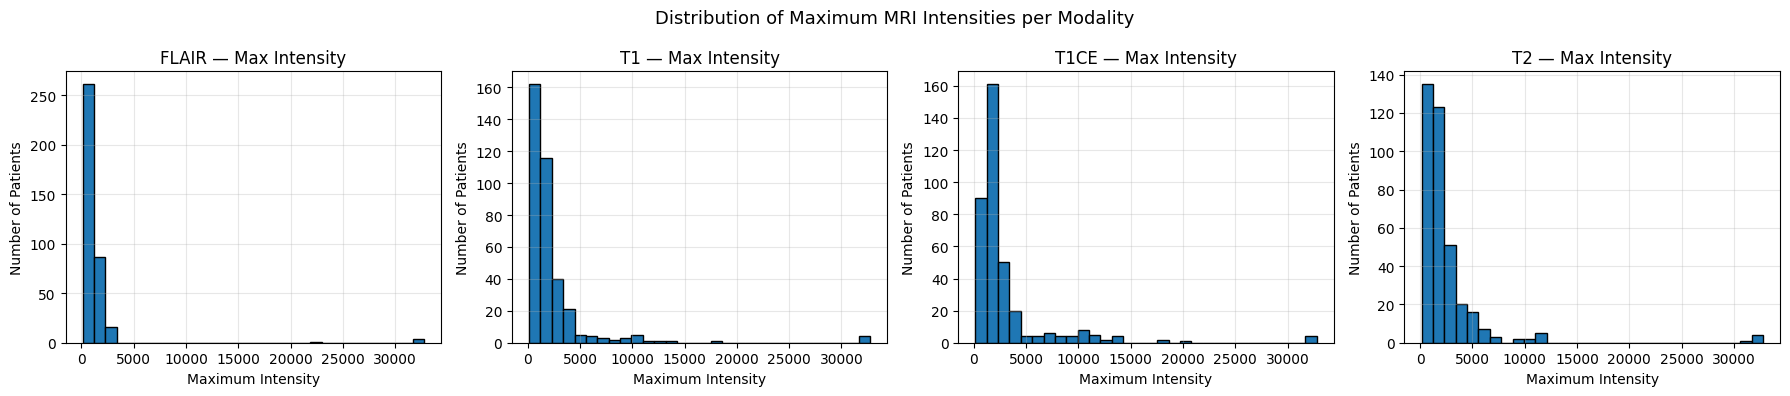

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, modality in zip(axes, MODALITIES_TO_CHECK):

    ax.hist(
        intensity_df[f'{modality}_max'],
        bins=30,
        edgecolor='black'
    )

    ax.set_title(f'{modality.upper()} — Max Intensity')
    ax.set_xlabel('Maximum Intensity')
    ax.set_ylabel('Number of Patients')
    ax.grid(alpha=0.3)

plt.suptitle('Distribution of Maximum MRI Intensities per Modality', fontsize=13)
plt.tight_layout()
plt.show()


## Distribution of Mean MRI Intensities

This histogram shows how the average intensity varies across patients.

The observed variability further confirms the need for intensity normalization before training.

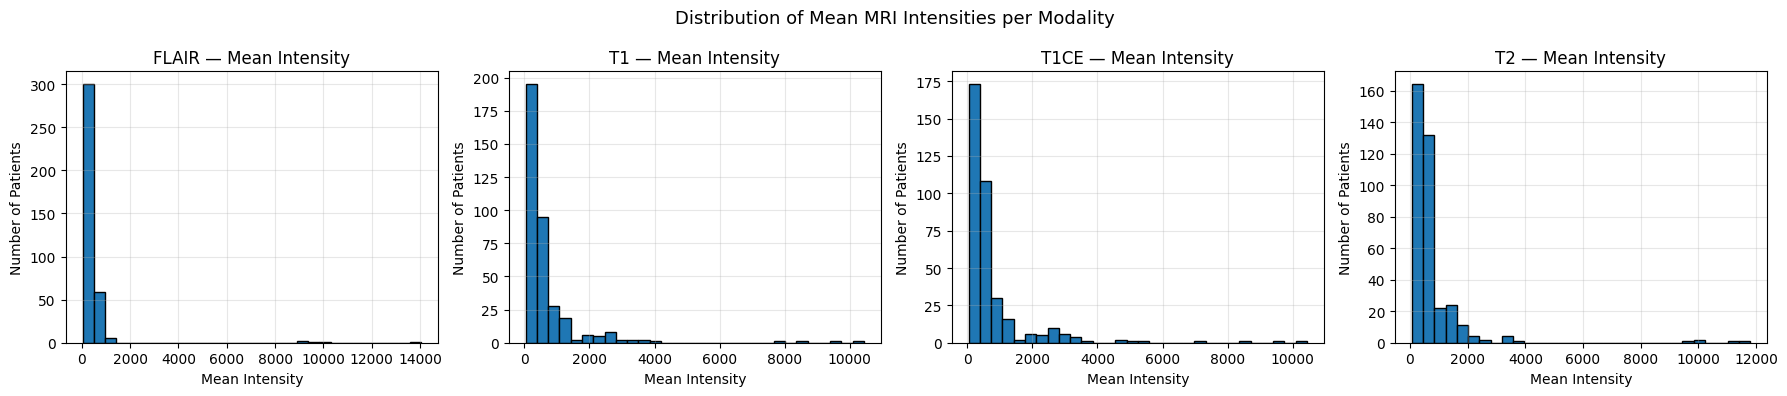

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, modality in zip(axes, MODALITIES_TO_CHECK):

    ax.hist(
        intensity_df[f'{modality}_mean'],
        bins=30,
        edgecolor='black'
    )

    ax.set_title(f'{modality.upper()} — Mean Intensity')
    ax.set_xlabel('Mean Intensity')
    ax.set_ylabel('Number of Patients')
    ax.grid(alpha=0.3)

plt.suptitle('Distribution of Mean MRI Intensities per Modality', fontsize=13)
plt.tight_layout()
plt.show()


## Boxplot of Maximum Intensities

A boxplot provides a compact summary of the intensity distribution and highlights potential outliers.

Extreme intensity values may influence normalization and therefore should be considered during preprocessing.

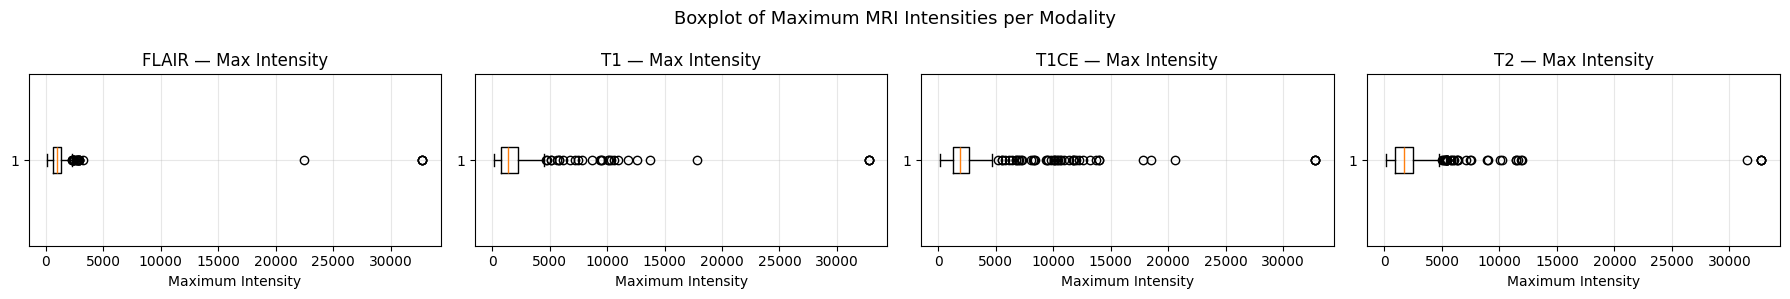

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3))

for ax, modality in zip(axes, MODALITIES_TO_CHECK):

    ax.boxplot(
        intensity_df[f'{modality}_max'],
        vert=False
    )

    ax.set_title(f'{modality.upper()} — Max Intensity')
    ax.set_xlabel('Maximum Intensity')
    ax.grid(alpha=0.3)

plt.suptitle('Boxplot of Maximum MRI Intensities per Modality', fontsize=13)
plt.tight_layout()
plt.show()


## Patients with Highest Maximum Intensities

The following table lists the patients with the highest maximum intensity values.

These scans will be reviewed during preprocessing to determine whether intensity clipping is required.

In [29]:
# Top 10 patients with highest T1ce max intensity (most likely to have outliers)
intensity_df.sort_values(
    by='t1ce_max',
    ascending=False
)[['Patient', 'flair_max', 't1_max', 't1ce_max', 't2_max']].head(10)


,Patient,flair_max,t1_max,t1ce_max,t2_max
312,BraTS20_Training_313,32767.000000,32767.000000,32767.0,32767.0
276,BraTS20_Training_277,32767.000000,32767.000000,32767.0,32767.0
314,BraTS20_Training_315,32767.000000,32767.000000,32767.0,32767.0
315,BraTS20_Training_316,32767.000000,32767.000000,32767.0,32767.0
355,BraTS20_Training_356,3247.000000,8642.000000,20619.0,5404.0
352,BraTS20_Training_353,2902.000000,2693.000000,18543.0,6296.0
363,BraTS20_Training_364,1908.000000,17828.000000,17828.0,7061.0
368,BraTS20_Training_369,2727.000000,2534.200439,13997.0,4965.0
367,BraTS20_Training_368,2039.101562,2186.417236,13977.0,6020.0
349,BraTS20_Training_350,2348.000000,13770.000000,13770.0,6427.0


### Observation

Intensity statistics were computed using only the foreground voxels (brain tissue), excluding the zero-valued background.

This provides a more representative estimate of MRI intensity characteristics across all four modalities.

The analysis shows that:

- MRI intensities vary substantially across patients **and across modalities**.
- **T1ce** consistently shows the highest maximum intensities due to the contrast agent effect.
- A small number of scans contain extremely high intensity values (up to **32767**), visible as outliers in the boxplots.
- **FLAIR** and **T2** show relatively more stable intensity ranges compared to T1 and T1ce.

Based on these findings, the preprocessing pipeline will apply normalization **per modality independently**:

1. Exclude background voxels (zero-valued).
2. Apply percentile-based intensity clipping (1st–99th percentile) per modality.
3. Perform Z-score normalization on foreground voxels per modality.

This per-modality strategy preserves the clinically meaningful differences between modalities while removing extreme outliers.


# Validation Check 7 — Tumor Region Distribution

Understanding how tumor subregions are distributed across slices is essential before designing the training pipeline.

Tumor regions are highly imbalanced — the enhancing tumor (ET) occupies far fewer voxels than the whole tumor (WT).

This analysis will directly inform:

- The choice of **loss function** (e.g., Dice loss to handle imbalance).
- The decision to **filter empty slices** before training.
- Any **class weighting** strategy applied during training.

In [30]:
label_voxel_counts = {0: 0, 1: 0, 2: 0, 4: 0}

for patient in tqdm(patients):

    seg_path = get_modality_path(patient, 'seg')

    mask = nib.load(str(seg_path)).get_fdata().astype(int)

    for label in [0, 1, 2, 4]:
        label_voxel_counts[label] += int((mask == label).sum())


  0%|          | 0/369 [00:00<?, ?it/s]

In [31]:
total_voxels = sum(label_voxel_counts.values())

label_names = {
    0: 'Background',
    1: 'NCR/NET (Necrotic Core)',
    2: 'Edema (ED)',
    4: 'Enhancing Tumor (ET)'
}

print(f'{'Label':<5} {'Region':<30} {'Voxels':>15} {'Percentage':>12}')
print('-' * 65)

for label, count in label_voxel_counts.items():
    pct = count / total_voxels * 100
    print(f'{label:<5} {label_names[label]:<30} {count:>15,} {pct:>11.4f}%')


Label Region                                  Voxels   Percentage
-----------------------------------------------------------------
0     Background                       3,257,699,276     98.8850%
1     NCR/NET (Necrotic Core)              8,161,996      0.2478%
2     Edema (ED)                          21,302,318      0.6466%
4     Enhancing Tumor (ET)                 7,268,410      0.2206%


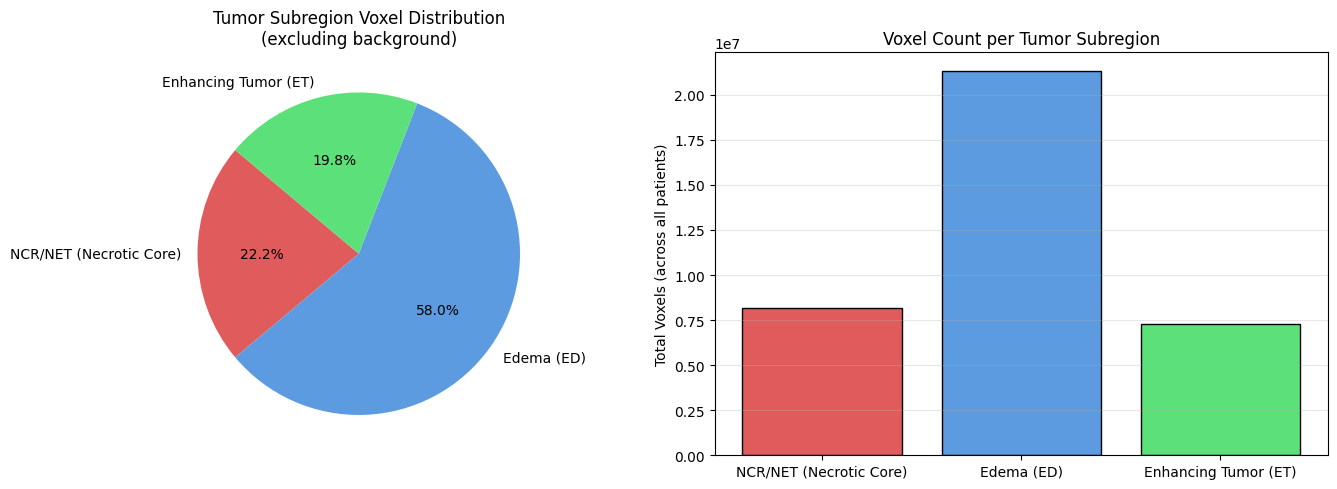

In [32]:
# Pie chart of tumor region distribution (excluding background)
tumor_labels  = {k: v for k, v in label_voxel_counts.items() if k != 0}
names  = [label_names[k] for k in tumor_labels]
values = list(tumor_labels.values())
colors = ['#E05C5C', '#5C9BE0', '#5CE07A']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    values,
    labels=names,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
axes[0].set_title('Tumor Subregion Voxel Distribution\n(excluding background)')

axes[1].bar(
    names,
    values,
    color=colors,
    edgecolor='black'
)
axes[1].set_title('Voxel Count per Tumor Subregion')
axes[1].set_ylabel('Total Voxels (across all patients)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Observation

The tumor region distribution confirms a significant class imbalance across all patients:

- **Edema (ED)** occupies the largest tumor region — it surrounds the tumor core.
- **Necrotic Core (NCR/NET)** is the second largest region.
- **Enhancing Tumor (ET)** is the smallest and rarest region — often only a few voxels per slice.

This imbalance has direct consequences for model training:

1. **Standard cross-entropy loss** will be dominated by the background class and will fail to learn ET boundaries.
2. **Dice loss** handles this naturally by focusing on overlap ratio rather than raw voxel counts.
3. **Empty slices** (no tumor present) should be filtered or downsampled before training to avoid wasting compute on background-only samples.


# Validation Check 8 — File Integrity

Before proceeding to preprocessing, we verify that all MRI volumes and segmentation masks can be successfully loaded.

This step helps detect corrupted or unreadable NIfTI files that could interrupt the training pipeline.

In [33]:
corrupted_files = []

for patient in tqdm(patients):

    try:

        for file in patient.glob("*.nii"):

            nib.load(str(file))

    except Exception as e:

        corrupted_files.append(
            {
                "Patient": patient.name,
                "File": file.name,
                "Error": str(e)
            }
        )

  0%|          | 0/369 [00:00<?, ?it/s]

In [34]:
print("Corrupted Files:", len(corrupted_files))

if len(corrupted_files) == 0:
    print("✅ All MRI volumes and segmentation masks were loaded successfully.")

Corrupted Files: 0
✅ All MRI volumes and segmentation masks were loaded successfully.


In [35]:
validation_report = pd.DataFrame({
    'Validation Check': [
        'Patient Count',
        'Patient File Count',
        'File Naming',
        'MRI Shape',
        'MRI-Mask Shape Consistency',
        'Segmentation Labels',
        'MRI Intensity Statistics (All Modalities)',
        'Tumor Region Distribution',
        'File Integrity'
    ],
    'Result': [
        '369 Patients',
        'All Patients Contain 5 Files',
        'Robust Validation (Patient 355 handled)',
        'Single Shape (240×240×155)',
        'Perfect Match',
        'Valid Labels Only',
        'Per-Modality Intensity Variation Detected',
        'High Imbalance — ET is rarest region',
        'No Corrupted Files'
    ],
    'Status': [
        'PASS', 'PASS', 'PASS', 'PASS', 'PASS',
        'PASS', 'PASS', 'PASS', 'PASS'
    ]
})

REPORTS_DIR = Path('reports')
REPORTS_DIR.mkdir(exist_ok=True)

validation_report


,Validation Check,Result,Status
0,Patient Count,369 Patients,PASS
1,Patient File Count,All Patients Contain 5 Files,PASS
2,File Naming,Robust Validation (Patient 355 handled),PASS
3,MRI Shape,Single Shape (240×240×155),PASS
4,MRI-Mask Shape Consistency,Perfect Match,PASS
5,Segmentation Labels,Valid Labels Only,PASS
6,MRI Intensity Statistics (All Modalities),Per-Modality Intensity Variation Detected,PASS
7,Tumor Region Distribution,High Imbalance — ET is rarest region,PASS
8,File Integrity,No Corrupted Files,PASS


In [36]:
validation_report.to_csv(

    REPORTS_DIR / "dataset_validation_report.csv",

    index=False
)

In [37]:
print(
    "Validation report saved successfully!"
)

Validation report saved successfully!


In [38]:
intensity_df.to_csv(

    REPORTS_DIR / 'mri_intensity_statistics.csv',

    index=False

)


In [39]:
print(
    "MRI intensity statistics saved successfully!"
)

MRI intensity statistics saved successfully!


In [40]:
list(REPORTS_DIR.iterdir())

[PosixPath('reports/mri_intensity_statistics.csv'),
 PosixPath('reports/dataset_validation_report.csv')]

# Notebook Summary

In this notebook, a comprehensive validation of the BraTS2020 dataset was performed before any preprocessing or model development.

### Completed Validation Steps

- Verified the total number of patients.
- Confirmed that every patient folder contains all required MRI files.
- Validated MRI modality naming while handling irregular filenames robustly.
- Confirmed consistent MRI volume dimensions across the dataset.
- Verified voxel-wise consistency between MRI volumes and segmentation masks.
- Ensured that all segmentation masks contain only valid BraTS2020 labels.
- Analyzed MRI intensity statistics **across all four modalities** and identified the need for per-modality normalization.
- Quantified tumor subregion distribution and confirmed significant class imbalance.
- Verified that all MRI volumes and segmentation masks can be successfully loaded.

### Key Findings

| Finding | Impact on Next Stage |
|---------|---------------------|
| All volumes are (240×240×155) | No spatial resampling needed |
| Intensity varies across patients and modalities | Per-modality Z-score normalization required |
| Outlier intensities up to 32767 | Percentile clipping (1–99%) before normalization |
| ET is the rarest tumor region | Dice loss + empty slice filtering required |
| Patient 355 has non-standard seg filename | Robust keyword-based file detection used |

The dataset passed all validation checks and is ready for the preprocessing stage.
